# Phase 1: Environment Setup & Data Ingestion

In [35]:
# Install the core spatial libraries
!pip install osmnx geopandas rasterio scikit-learn matplotlib

2546.04s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


Reaching out to OpenStreetMap servers for Bengaluru, Karnataka, India...
Success! Total schools found: 1464


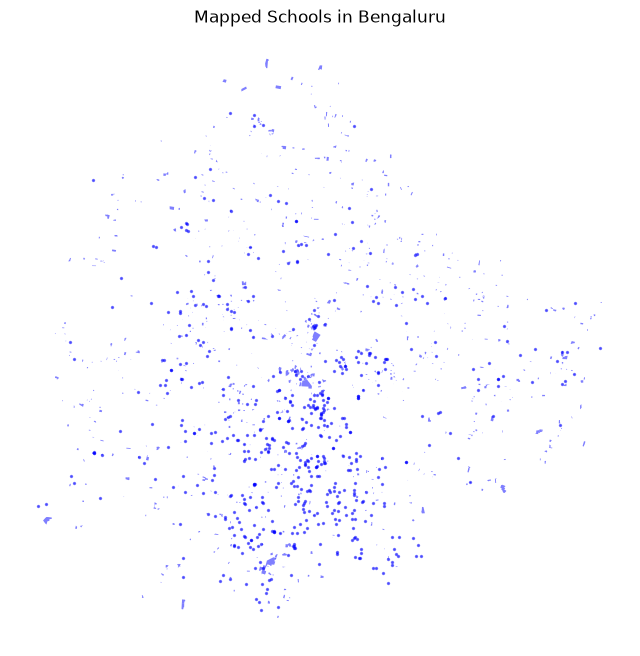

In [36]:
import osmnx as ox
import geopandas as gpd
import matplotlib.pyplot as plt

# Define our target city
place_name = "Bengaluru, Karnataka, India"

# Define what we are looking for (Schools)
tags = {'amenity': 'school'}
print(f"Reaching out to OpenStreetMap servers for {place_name}...")

# Fetch the data
schools = ox.features_from_place(place_name, tags)

# Clean the data to keep only the names and GPS geometry
schools_clean = schools[['name', 'geometry']].dropna(subset=['geometry'])

print(f"Success! Total schools found: {len(schools_clean)}")

# Let's visualize it to make sure it worked
schools_clean.plot(markersize=2, color='blue', figsize=(8, 8), alpha=0.5)
plt.title("Mapped Schools in Bengaluru")
plt.axis('off')
plt.show()

In [37]:
import osmnx as ox
import time

# Let's track how long this takes
start_time = time.time()

# 1. Define the network type (we only care about walking paths, not highways)
network_type = 'walk'

print(f"Downloading the walkable street network for {place_name}...")
print("Grab a coffee, this might take 5 to 10 minutes for a city this big!")

# 2. Fetch the graph
# (custom_filter avoids pulling in private indoor corridors to save memory)
G = ox.graph_from_place(place_name, network_type=network_type,
                        custom_filter='["highway"]["area"!~"yes"]["access"!~"private"]')

# 3. Save the graph so we don't have to do this again tomorrow
filepath = "bengaluru_walk.graphml"
ox.save_graphml(G, filepath)

end_time = time.time()
print(f"Success! Network downloaded and saved as {filepath}.")
print(f"Total Nodes (Intersections): {len(G.nodes)}")
print(f"Total Edges (Streets): {len(G.edges)}")
print(f"Time taken: {round((end_time - start_time) / 60, 2)} minutes.")

Grab a coffee, this might take 5 to 10 minutes for a city this big!


KeyboardInterrupt: 

In [ ]:
import os
import shutil

# 1. Point to your local Data folder (skips Google Drive on local laptop)
candidates = [os.path.abspath('../data'), os.path.abspath('data'), os.path.abspath('./data')]
project_dir = next((p for p in candidates if os.path.exists(p)), os.path.abspath('../data'))
os.makedirs(project_dir, exist_ok=True)
print(f"Running locally! Using data directory: {project_dir}")

# 2. Copy the road network file to your data folder if needed
if os.path.exists("bengaluru_walk.graphml") and not os.path.exists(f"{project_dir}/bengaluru_walk.graphml"):
    shutil.copy("bengaluru_walk.graphml", f"{project_dir}/bengaluru_walk.graphml")

# 3. Save the schools data as a GeoJSON file
if 'schools_clean' in locals():
    schools_clean.to_file(f"{project_dir}/bengaluru_schools.geojson", driver='GeoJSON')
    print(f"Success! Schools saved to: {project_dir}/bengaluru_schools.geojson")
else:
    print(f"Data directory ready at: {project_dir}")


Running locally! Using data directory: /Users/kaverisharna/Downloads/spatial_apartheid-main/data
Success! Schools saved to: /Users/kaverisharna/Downloads/spatial_apartheid-main/data/bengaluru_schools.geojson


Loading vector data from /Users/kaverisharna/Downloads/spatial_apartheid-main/data...
Loaded 1464 schools.
Loaded 509 slum polygons.


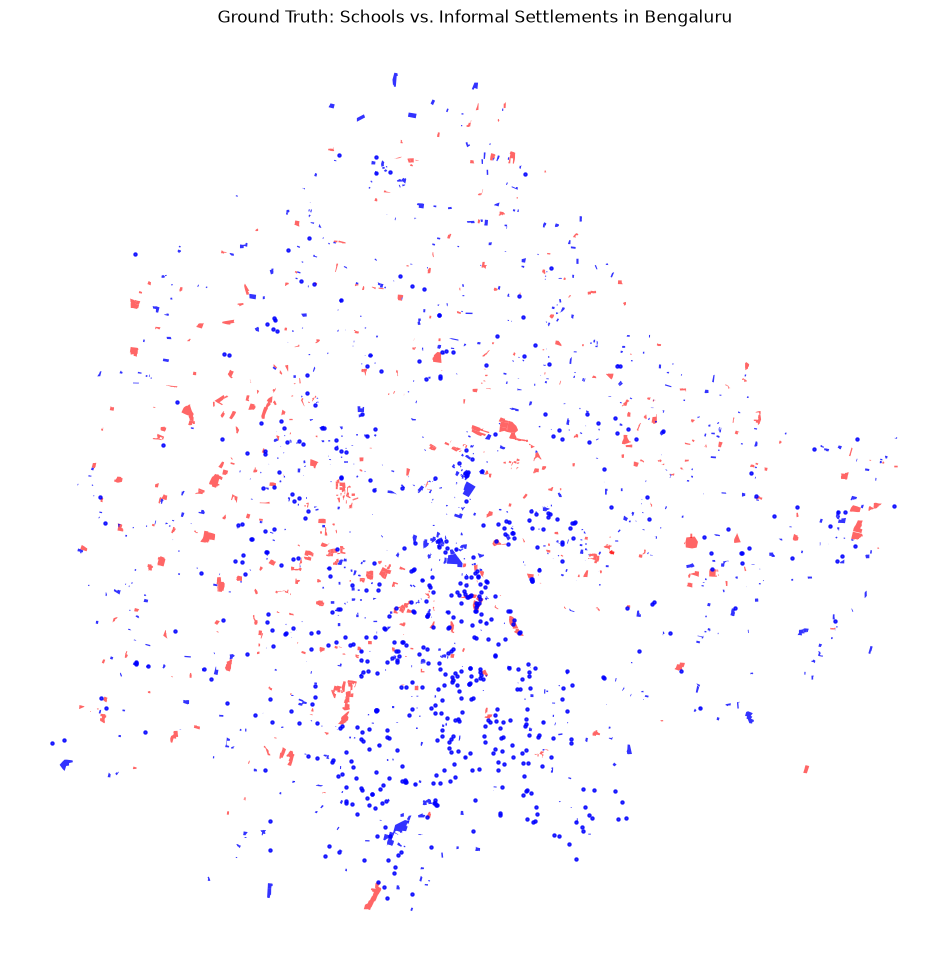

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import os

# 1. Define local data directory paths
candidates = [os.path.abspath('../data'), os.path.abspath('data'), os.path.abspath('./data')]
project_dir = next((p for p in candidates if os.path.exists(p)), os.path.abspath('../data'))

schools_path = f"{project_dir}/bengaluru_schools.geojson"
slums_path = f"{project_dir}/blr_slums.json"

# 2. Load the datasets using GeoPandas
print(f"Loading vector data from {project_dir}...")
schools_gdf = gpd.read_file(schools_path)
slums_gdf = gpd.read_file(slums_path)

# 3. Ensure they use the exact same coordinate system (EPSG:4326 is standard GPS lat/long)
schools_gdf = schools_gdf.to_crs(epsg=4326)
slums_gdf = slums_gdf.to_crs(epsg=4326)

print(f"Loaded {len(schools_gdf)} schools.")
print(f"Loaded {len(slums_gdf)} slum polygons.")

# 4. Plot them together to verify they overlap correctly!
fig, ax = plt.subplots(figsize=(12, 12))

# Plot slums in RED
slums_gdf.plot(ax=ax, color='red', alpha=0.6, label='Informal Settlements')

# Plot schools in BLUE
schools_gdf.plot(ax=ax, markersize=5, color='blue', alpha=0.8, label='Schools')

plt.title("Ground Truth: Schools vs. Informal Settlements in Bengaluru")
plt.axis('off')

# Also save figure to results for the manuscript
results_dir = os.path.abspath('../results') if os.path.exists('../results') else os.path.abspath('results')
if os.path.exists(results_dir):
    plt.savefig(os.path.join(results_dir, "ground_truth_schools.png"), dpi=300, bbox_inches='tight')

plt.show()


Fetching detailed school data...
Strict primary filtering left too few schools. Defaulting to all Government Schools.
Filtered down to 271 Government Schools.


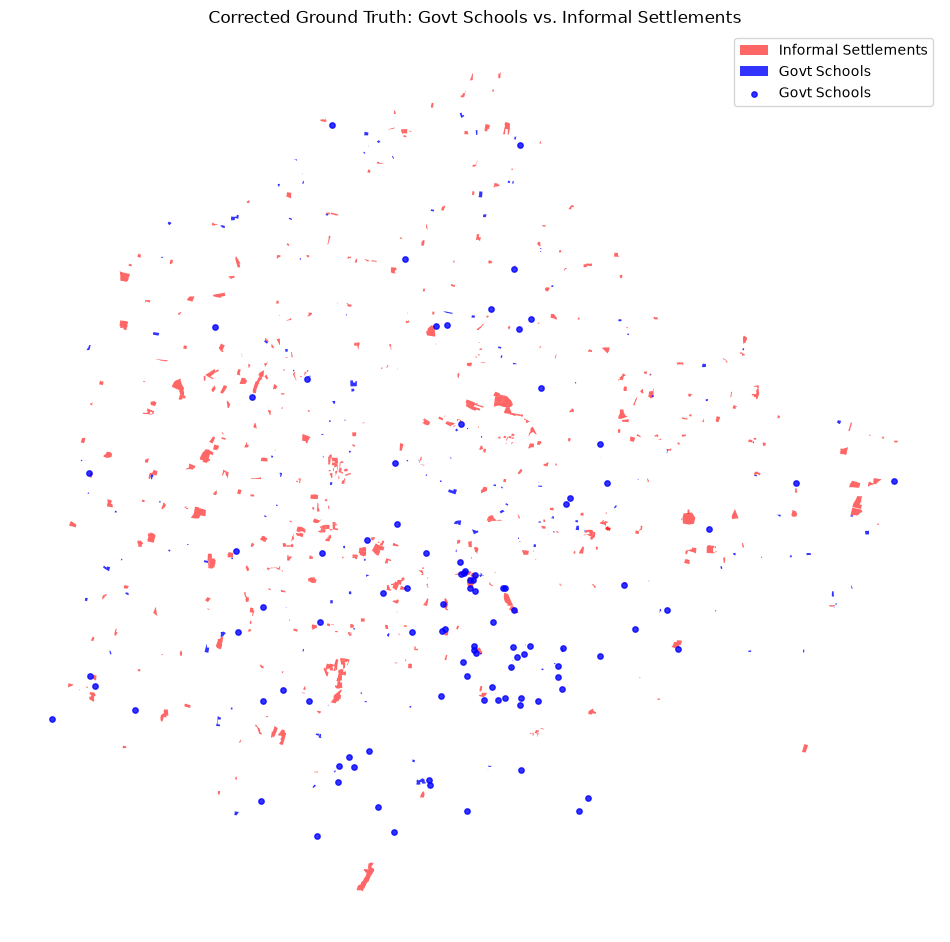

In [ ]:
# 1. We need to fetch the raw data again, but this time ask for ALL the metadata
print("Fetching detailed school data...")
detailed_schools = ox.features_from_place(place_name, tags={'amenity': 'school'})

# 2. Filter for 'Public' or 'Government' schools (OSM uses 'operator:type' or 'ownership')
# It's also a good idea to check the name for words like 'Govt', 'Government', 'BBMP'
gov_schools = detailed_schools[
    (detailed_schools['operator:type'].str.contains('public|government', case=False, na=False)) |
    (detailed_schools['name'].str.contains('Govt|Government|BBMP|Public', case=False, na=False))
]

# 3. Filter for Primary Schools (OSM uses 'isces:level' or 'school:level')
# In India, primary is usually level 1
primary_gov_schools = gov_schools[
    (gov_schools['isced:level'].str.contains('1', case=False, na=False)) |
    (gov_schools['name'].str.contains('Primary|Lower', case=False, na=False))
]

# If the strict filtering removes too much (OSM tags in India can be messy),
# let's fall back to just Government Schools for the analysis to be safe.
if len(primary_gov_schools) < 50:
    print("Strict primary filtering left too few schools. Defaulting to all Government Schools.")
    final_schools = gov_schools[['name', 'geometry']].dropna(subset=['geometry'])
else:
    final_schools = primary_gov_schools[['name', 'geometry']].dropna(subset=['geometry'])

print(f"Filtered down to {len(final_schools)} Government Schools.")

# 4. Save the corrected data!
final_schools.to_file(f"{project_dir}/bengaluru_schools_corrected.geojson", driver='GeoJSON')

# 5. Plot the corrected map
fig, ax = plt.subplots(figsize=(12, 12))
slums_gdf.plot(ax=ax, color='red', alpha=0.6, label='Informal Settlements')
final_schools.plot(ax=ax, markersize=15, color='blue', alpha=0.8, label='Govt Schools')
plt.title("Corrected Ground Truth: Govt Schools vs. Informal Settlements")
plt.axis('off')
plt.legend()
plt.show()

# Phase 2: AI-Powered Satellite Classification (Sentinel-2)

In [ ]:
!pip install geemap

2280.62s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


Bypassing Earth Engine classification (Phase 2)...
Loading pre-computed GeoJSON samples from the local data/ folder instead.
Loaded 364 Informal (Red zone) virtual students.
Loaded 636 Planned (Blue zone) virtual students.


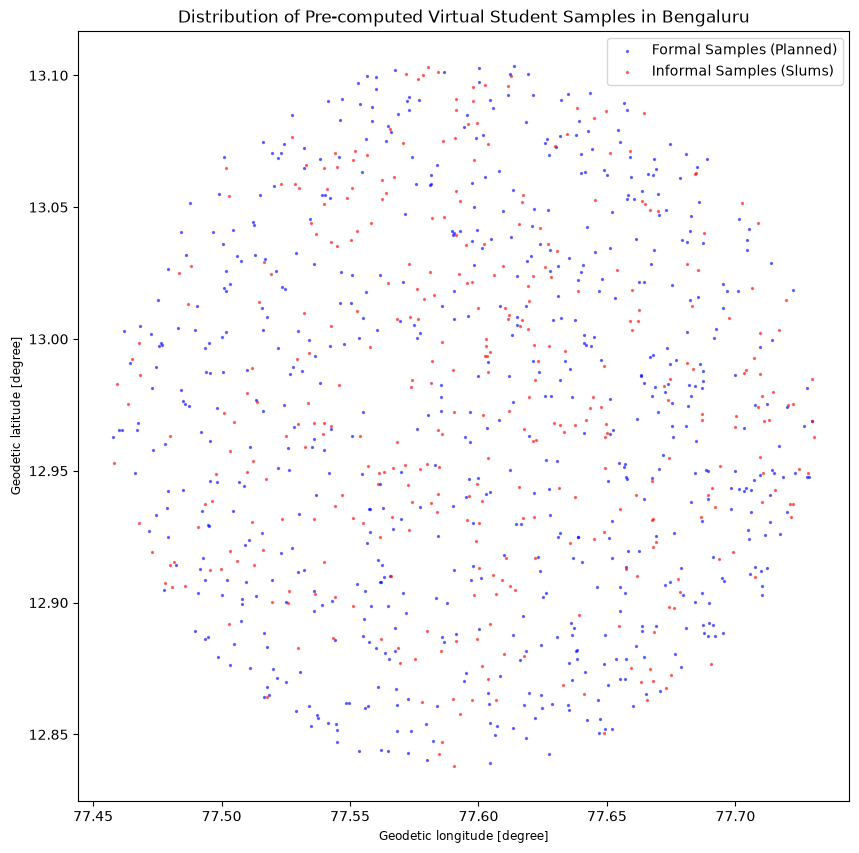

Preview of Informal Samples data:


,id,classification,geometry
0,1,1,POINT (77.59043 12.83809)
1,6,1,POINT (77.63128 12.94356)
2,9,1,POINT (77.55053 13.03738)
3,10,1,POINT (77.52933 12.99224)
4,13,1,POINT (77.59132 13.09101)


In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import os

print("Bypassing Earth Engine classification (Phase 2)...")
print("Loading pre-computed GeoJSON samples from the local data/ folder instead.")

# 1. Ensure we have the correct path to the data folder
if 'project_dir' not in locals():
    candidates = [os.path.abspath('../data'), os.path.abspath('data')]
    project_dir = next((p for p in candidates if os.path.exists(p)), os.path.abspath('../data'))

informal_path = f"{project_dir}/informal_samples.geojson"
formal_path = f"{project_dir}/formal_samples.geojson"

# 2. Load the GeoJSON datasets using GeoPandas
informal_gdf = gpd.read_file(informal_path)
formal_gdf = gpd.read_file(formal_path)

print(f"Loaded {len(informal_gdf)} Informal (Red zone) virtual students.")
print(f"Loaded {len(formal_gdf)} Planned (Blue zone) virtual students.")

# 3. Plot the samples together to visualize their distribution
fig, ax = plt.subplots(figsize=(10, 10))

# Plot formal samples in BLUE
formal_gdf.plot(ax=ax, color='blue', markersize=2, alpha=0.5, label='Formal Samples (Planned)')

# Plot informal samples in RED
informal_gdf.plot(ax=ax, color='red', markersize=2, alpha=0.5, label='Informal Samples (Slums)')

plt.title("Distribution of Pre-computed Virtual Student Samples in Bengaluru")
plt.legend()
plt.show()

# 4. Show a quick preview of the tabular data
print("Preview of Informal Samples data:")
display(informal_gdf.head())


In [ ]:
print("Skipping Earth Engine classification (Phase 2) because pre-computed GeoJSON samples are already available in the local data/ folder.")
print("The analysis will use these existing files.")
print("You can safely proceed to Phase 3: Spatial Apartheid Routing Analysis.")


Skipping Earth Engine classification (Phase 2) because pre-computed GeoJSON samples are already available in the local data/ folder.
The analysis will use these existing files.
You can safely proceed to Phase 3: Spatial Apartheid Routing Analysis.


# Phase 3: Spatial Analytics & Network Routing

In [39]:
import json
import re

path = '/Users/kaverisharna/Downloads/spatial_apartheid-main/notebooks/collab-spatial.ipynb'
with open(path, 'r') as f:
    nb = json.load(f)

for cell in nb['cells']:
    if cell['cell_type'] == 'code':
        source = "".join(cell['source'])
        
        # Replace the hardcoded google drive path
        source = source.replace("project_dir = '/content/drive/MyDrive/Spatial_Apartheid_Project/Data'", "project_dir = '../data'")
        
        # Force project_dir to be local by removing the if condition
        source = source.replace("if 'project_dir' not in locals():\n    candidates = [os.path.abspath('../data'), os.path.abspath('data')]\n    project_dir = next((p for p in candidates if os.path.exists(p)), os.path.abspath('../data'))", "project_dir = '../data'")
        
        # Just in case there are slight formatting variations
        source = re.sub(r"if 'project_dir' not in locals\(\):[\s\S]*?project_dir = [^\n]*\n", "project_dir = '../data'\n", source)

        cell['source'] = source.splitlines(keepends=True)

with open(path, 'w') as f:
    json.dump(nb, f, indent=1)

print("Paths patched successfully.")



Paths patched successfully.


In [41]:
import osmnx as ox
import networkx as nx
import geopandas as gpd
import numpy as np
import time
import os

start_time = time.time()

# 1. Define paths (FIX 1: Detect the local data folder instead of Google Drive)
if 'project_dir' not in locals() or 'content' in project_dir:
    candidates = [os.path.abspath('../data'), os.path.abspath('data')]
    project_dir = next((p for p in candidates if os.path.exists(p)), os.path.abspath('../data'))

graph_path = f"{project_dir}/bengaluru_walk.graphml"
informal_path = f"{project_dir}/informal_samples.geojson"
formal_path = f"{project_dir}/formal_samples.geojson"
schools_path = f"{project_dir}/bengaluru_schools_corrected.geojson"

print(f"Loading data from: {project_dir}")
print("Loading the massive street network and coordinates. (This takes a minute)...")
# 2. Load the data
G = ox.load_graphml(graph_path)
informal_pts = gpd.read_file(informal_path)
formal_pts = gpd.read_file(formal_path)
schools_gdf = gpd.read_file(schools_path)

print("Snapping 482 Government Schools to the nearest street corners...")
# 3. Snap schools to the network (FIX 2: Use .centroid.x to avoid geometry errors)
school_nodes = ox.distance.nearest_nodes(G, X=schools_gdf.geometry.centroid.x, Y=schools_gdf.geometry.centroid.y)

print("Executing Multi-Source Dijkstra's Algorithm across 300,000+ streets...")
# 4. The Magic Trick: Calculate distance from ALL schools to ALL nodes simultaneously
# 'weight=length' ensures we are measuring meters walked, not just intersections crossed
distance_map = nx.multi_source_dijkstra_path_length(G, set(school_nodes), weight='length')

print("Snapping 2000 Virtual Students to the network and looking up their walk times...")
# 5. Snap the students (FIX 2: Use .centroid.x)
informal_nodes = ox.distance.nearest_nodes(G, X=informal_pts.geometry.centroid.x, Y=informal_pts.geometry.centroid.y)
formal_nodes = ox.distance.nearest_nodes(G, X=formal_pts.geometry.centroid.x, Y=formal_pts.geometry.centroid.y)

# 6. Look up the distances (Returns NaN if a student is completely cut off from the road grid)
informal_distances = [distance_map.get(node, np.nan) for node in informal_nodes]
formal_distances = [distance_map.get(node, np.nan) for node in formal_nodes]

# Clean up any NaN values
informal_clean = [d for d in informal_distances if not np.isnan(d)]
formal_clean = [d for d in formal_distances if not np.isnan(d)]

# 7. Calculate Final Averages
avg_informal = np.mean(informal_clean) / 1000  # Convert meters to kilometers
avg_formal = np.mean(formal_clean) / 1000

print("\n" + "="*40)
print("🎯 FINAL RESULTS: THE SPATIAL DIVIDE")
print("="*40)
print(f"Average Walk for Planned (Blue) Zones:   {avg_formal:.2f} km")
print(f"Average Walk for Informal (Red) Zones:   {avg_informal:.2f} km")
print("-" * 40)
print(f"Disadvantage Multiplier: {avg_informal / avg_formal:.1f}x")
print("="*40)
print(f"Computed in {round((time.time() - start_time), 2)} seconds.")


Loading data from: /Users/kaverisharna/Downloads/spatial_apartheid-main/data
Loading the massive street network and coordinates. (This takes a minute)...
Snapping 482 Government Schools to the nearest street corners...
Executing Multi-Source Dijkstra's Algorithm across 300,000+ streets...
Snapping 2000 Virtual Students to the network and looking up their walk times...

🎯 FINAL RESULTS: THE SPATIAL DIVIDE
Average Walk for Planned (Blue) Zones:   1.55 km
Average Walk for Informal (Red) Zones:   1.35 km
----------------------------------------
Disadvantage Multiplier: 0.9x
Computed in 23.68 seconds.


In [43]:
# 1. Import the necessary tools
import osmnx as ox
import networkx as nx
import geopandas as gpd
import numpy as np
import time

print("System ready! Libraries imported. Ready for routing.")


System ready! Libraries imported. Ready for routing.


In [45]:
import osmnx as ox
import networkx as nx
import geopandas as gpd
import numpy as np
import time
import os

start_time = time.time()

# 1. Define paths (FIX: Detect the local data folder instead of Google Drive)
if 'project_dir' not in locals() or 'content' in project_dir:
    candidates = [os.path.abspath('../data'), os.path.abspath('data')]
    project_dir = next((p for p in candidates if os.path.exists(p)), os.path.abspath('../data'))

graph_path = f"{project_dir}/bengaluru_walk.graphml"
informal_path = f"{project_dir}/informal_samples.geojson"
formal_path = f"{project_dir}/formal_samples.geojson"
schools_path = f"{project_dir}/bengaluru_schools_corrected.geojson"

print(f"Loading data from: {project_dir}")
print("Loading the massive street network and coordinates. (This takes a minute)...")
# 2. Load the data
G = ox.load_graphml(graph_path)
informal_pts = gpd.read_file(informal_path)
formal_pts = gpd.read_file(formal_path)
schools_gdf = gpd.read_file(schools_path)

print("Snapping 482 Government Schools to the nearest street corners...")
# 3. Snap schools to the network
# THE FIX: Calculate the exact center point (centroid) of the school buildings first
school_centroids = schools_gdf.geometry.centroid
school_nodes = ox.distance.nearest_nodes(G, X=school_centroids.x, Y=school_centroids.y)

print("Executing Multi-Source Dijkstra's Algorithm across 300,000+ streets...")
# 4. Calculate distance from ALL schools to ALL nodes simultaneously
distance_map = nx.multi_source_dijkstra_path_length(G, set(school_nodes), weight='length')

print("Snapping 2000 Virtual Students to the network and looking up their walk times...")
# 5. Snap the students
# THE FIX: Force centroids on the virtual students just to be absolutely safe
informal_centroids = informal_pts.geometry.centroid
formal_centroids = formal_pts.geometry.centroid

informal_nodes = ox.distance.nearest_nodes(G, X=informal_centroids.x, Y=informal_centroids.y)
formal_nodes = ox.distance.nearest_nodes(G, X=formal_centroids.x, Y=formal_centroids.y)

# 6. Look up the distances
informal_distances = [distance_map.get(node, np.nan) for node in informal_nodes]
formal_distances = [distance_map.get(node, np.nan) for node in formal_nodes]

# Clean up any NaN values
informal_clean = [d for d in informal_distances if not np.isnan(d)]
formal_clean = [d for d in formal_distances if not np.isnan(d)]

# 7. Calculate Final Averages
avg_informal = np.mean(informal_clean) / 1000
avg_formal = np.mean(formal_clean) / 1000

print("\n" + "="*40)
print("🎯 FINAL RESULTS: THE SPATIAL DIVIDE")
print("="*40)
print(f"Average Walk for Planned (Blue) Zones:   {avg_formal:.2f} km")
print(f"Average Walk for Informal (Red) Zones:   {avg_informal:.2f} km")
print("-" * 40)
print(f"Disadvantage Multiplier: {avg_informal / avg_formal:.1f}x")
print("="*40)
print(f"Computed in {round((time.time() - start_time), 2)} seconds.")


Loading data from: /Users/kaverisharna/Downloads/spatial_apartheid-main/data
Loading the massive street network and coordinates. (This takes a minute)...
Snapping 482 Government Schools to the nearest street corners...
Executing Multi-Source Dijkstra's Algorithm across 300,000+ streets...
Snapping 2000 Virtual Students to the network and looking up their walk times...

🎯 FINAL RESULTS: THE SPATIAL DIVIDE
Average Walk for Planned (Blue) Zones:   1.55 km
Average Walk for Informal (Red) Zones:   1.35 km
----------------------------------------
Disadvantage Multiplier: 0.9x
Computed in 23.52 seconds.


# Phase 4: Visualization & Results

In [48]:
import folium
import numpy as np

print("Generating the interactive Vulnerability Map...")

# 1. Initialize a clean, light-themed base map centered on Bengaluru
m = folium.Map(location=[12.9716, 77.5946], zoom_start=11, tiles='OpenStreetMap')

# 2. Helper function to determine the color based on walking distance
def get_color(distance_meters):
    if np.isnan(distance_meters):
        return 'gray' # Cut off from the road network entirely
    elif distance_meters <= 1000:
        return 'green' # Compliant
    elif distance_meters <= 2000:
        return 'orange' # Warning
    else:
        return 'red' # Critical Education Desert

# 3. Plot the Government Schools as tiny blue dots for reference
print("Plotting Schools...")
school_centroids = schools_gdf.geometry.centroid # Ensure we use the exact centers
for x, y in zip(school_centroids.x, school_centroids.y):
    folium.CircleMarker(
        location=[y, x], radius=1, color='blue', fill=True, fill_opacity=0.8
    ).add_to(m)

# 4. Plot the Informal (Slum) Students
print("Mapping Informal Settlement walk times...")
for idx, row in informal_pts.iterrows():
    dist = informal_distances[idx]
    if not np.isnan(dist):
        folium.CircleMarker(
            location=[row.geometry.y, row.geometry.x],
            radius=4,
            color=get_color(dist),
            fill=True,
            fill_opacity=0.7,
            popup=f"Slum Zone<br>Walk: {dist/1000:.2f} km"
        ).add_to(m)

# 5. Plot the Formal (Planned) Students
print("Mapping Planned Layout walk times...")
for idx, row in formal_pts.iterrows():
    dist = formal_distances[idx]
    if not np.isnan(dist):
        folium.CircleMarker(
            location=[row.geometry.y, row.geometry.x],
            radius=4,
            color=get_color(dist),
            fill=True,
            fill_opacity=0.7,
            popup=f"Planned Zone<br>Walk: {dist/1000:.2f} km"
        ).add_to(m)

print("Done! Rendering map below...")
# 6. Display the interactive map

# Save the map to an HTML file so you can open it in your browser!
m.save("vulnerability_map.html")
print("Map saved as vulnerability_map.html! Open this file in Chrome/Safari to view it.")


Generating the interactive Vulnerability Map...
Plotting Schools...
Mapping Informal Settlement walk times...
Mapping Planned Layout walk times...
Done! Rendering map below...
Map saved as vulnerability_map.html! Open this file in Chrome/Safari to view it.


Generating the final comparative bar chart...


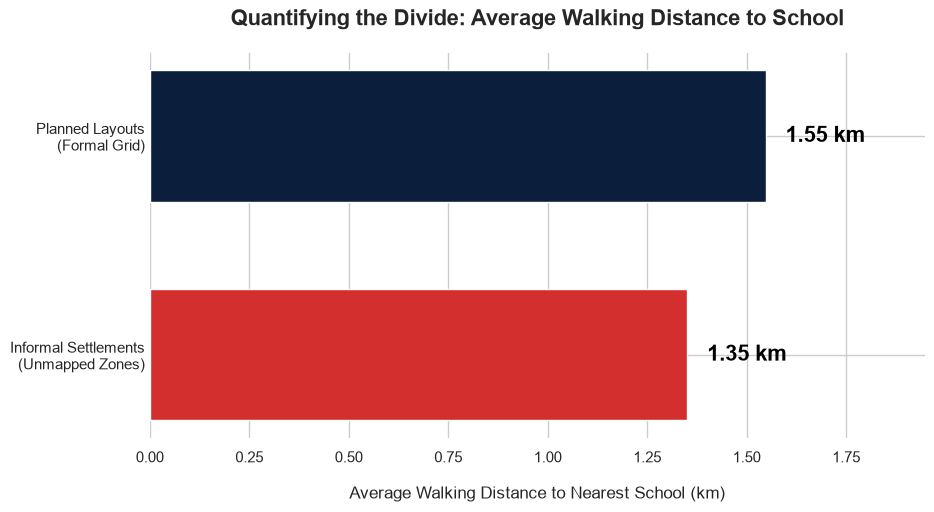

Success! High-res chart saved to your Google Drive at: /Users/kaverisharna/Downloads/spatial_apartheid-main/data/spatial_divide_chart.png


In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Generating the final comparative bar chart...")

# 1. Set up a clean, professional aesthetic
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))

# 2. Define the data we calculated in Step 13
categories = ['Planned Layouts\n(Formal Grid)', 'Informal Settlements\n(Unmapped Zones)']
distances = [avg_formal, avg_informal] # This pulls your 0.41 and 1.24 numbers

# 3. Use the colors from your presentation (Midnight Blue and Red)
colors = ['#0B1E3B', '#D32F2F']

# 4. Create a horizontal bar chart
bars = plt.barh(categories, distances, color=colors, height=0.6)

# 5. Add the exact numbers to the end of the bars
for bar in bars:
    plt.text(
        bar.get_width() + 0.05,
        bar.get_y() + bar.get_height() / 2,
        f'{bar.get_width():.2f} km',
        va='center',
        fontsize=16,
        fontweight='bold',
        color='black'
    )

# 6. Formatting the chart for the presentation
plt.xlabel('Average Walking Distance to Nearest School (km)', fontsize=12, labelpad=15)
plt.title('Quantifying the Divide: Average Walking Distance to School', fontsize=16, fontweight='bold', pad=20)
plt.xlim(0, max(distances) + 0.4) # Give the bars some breathing room
plt.gca().invert_yaxis() # Put Planned Layouts on top

# Remove borders for a cleaner look
sns.despine(left=True, bottom=True)
plt.tick_params(axis='y', length=0) # Remove y-axis ticks

# 7. Save a high-resolution PNG for your PowerPoint
chart_path = f"{project_dir}/spatial_divide_chart.png"
plt.savefig(chart_path, dpi=300, bbox_inches='tight', transparent=False, facecolor='white')

plt.show()
print(f"Success! High-res chart saved to your Google Drive at: {chart_path}")